In [ ]:
!pip install -q optbinning openpyxl joblib statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.8/214.8 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.1/28.1 MB 46.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.8/302.8 kB 18.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.20.0 requires protobuf>=5.28.0, but you have protobuf 5.26.1 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 5.26.1 which is incompatible.
grain 0.2.18 requires protobuf>=5.28.3, but you have protobuf 5.26.1 which is incompatible.


# Import lib

In [ ]:
from pathlib import Path
import json
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from optbinning import OptimalBinning

from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import (
    variance_inflation_factor
)

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
cleaned_dataset = pd.read_csv('/content/drive/MyDrive/AIO 2026/Conquer/Data/cleaned_dataset.csv')

In [ ]:
# ============================================================
# CẤU HÌNH CHUNG
# ============================================================

TARGET = "loan_status"

CATEGORICAL_FEATURES = [
    "person_home_ownership",
    "loan_intent",
    "loan_grade",
    "cb_person_default_on_file"
]

TEST_SIZE = 0.20
RANDOM_STATE = 42

# IV tối thiểu để đưa vào feature selection
IV_THRESHOLD = 0.02

# Cảnh báo chất lượng bin
SMALL_BIN_THRESHOLD = 0.05
EXTREME_WOE_THRESHOLD = 2.0

# Cấu hình Optimal Binning
BINNING_CONFIG = {
    "prebinning_method": "cart",
    "solver": "cp",
    "divergence": "iv",
    "max_n_prebins": 20,
    "min_prebin_size": 0.05,
    "max_n_bins": 6,
    "monotonic_trend": "auto"
}

# ------------------------------------------------------------
# Bối cảnh sử dụng mô hình
# ------------------------------------------------------------
#
# "all_available":
#     Giữ tất cả biến đã có trong dataset.
#
# "pre_decision":
#     Loại loan_grade và loan_int_rate vì hai biến này có thể
#     chỉ xuất hiện sau quá trình đánh giá/định giá khoản vay.
#
MODEL_CONTEXT = "all_available"

if MODEL_CONTEXT == "pre_decision":
    BUSINESS_EXCLUDE = [
        "loan_grade",
        "loan_int_rate"
    ]
else:
    BUSINESS_EXCLUDE = []

# ------------------------------------------------------------
# Đường dẫn lưu output
# ------------------------------------------------------------

OUTPUT_DIR = Path(
    "/content/drive/MyDrive/"
    "AIO 2026/Conquer/Data/"
    "train_test_feature_selection"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Output directory:")
print(OUTPUT_DIR)

Output directory:
/content/drive/MyDrive/AIO 2026/Conquer/Data/train_test_feature_selection


In [ ]:
def validate_cleaned_dataset(
    data,
    target,
    categorical_features
):
    """
    Kiểm tra cấu trúc dữ liệu trước khi chia train/test.
    """

    if not isinstance(data, pd.DataFrame):
        raise TypeError(
            "cleaned_dataset phải là pandas DataFrame."
        )

    if data.empty:
        raise ValueError(
            "cleaned_dataset không có quan sát."
        )

    if data.columns.duplicated().any():
        duplicated_columns = (
            data.columns[
                data.columns.duplicated()
            ]
            .tolist()
        )

        raise ValueError(
            f"Có tên cột bị trùng: {duplicated_columns}"
        )

    if target not in data.columns:
        raise KeyError(
            f"Không tìm thấy target '{target}'."
        )

    if data[target].isna().any():
        raise ValueError(
            f"Target '{target}' chứa missing values."
        )

    target_values = set(
        data[target]
        .unique()
        .tolist()
    )

    if target_values != {0, 1}:
        raise ValueError(
            f"{target} phải nhận đúng {{0, 1}}. "
            f"Hiện tại: {target_values}"
        )

    missing_categorical = [
        feature
        for feature in categorical_features
        if feature not in data.columns
    ]

    if missing_categorical:
        raise KeyError(
            "Không tìm thấy các biến categorical: "
            f"{missing_categorical}"
        )

    features = [
        column
        for column in data.columns
        if column != target
    ]

    numerical_features = [
        feature
        for feature in features
        if feature not in categorical_features
    ]

    print("=" * 70)
    print("KIỂM TRA CLEANED DATASET")
    print("=" * 70)

    print(f"Số quan sát: {len(data):,}")
    print(f"Số biến dự báo: {len(features)}")
    print(
        f"Tỷ lệ default: "
        f"{data[target].mean():.2%}"
    )

    print("\nNumerical features:")
    print(numerical_features)

    print("\nCategorical features:")
    print(categorical_features)

    return (
        features,
        numerical_features
    )

In [ ]:
FEATURES, NUMERICAL_FEATURES = (
    validate_cleaned_dataset(
        data=cleaned_dataset,
        target=TARGET,
        categorical_features=(
            CATEGORICAL_FEATURES
        )
    )
)

KIỂM TRA CLEANED DATASET
Số quan sát: 31,679
Số biến dự báo: 11
Tỷ lệ default: 21.54%

Numerical features:
['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']

Categorical features:
['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']


## Train/Test Split

In [ ]:
train_data, test_data = train_test_split(
    cleaned_dataset,
    test_size=TEST_SIZE,
    stratify=cleaned_dataset[TARGET],
    random_state=RANDOM_STATE,
    shuffle=True
)

train_data = train_data.copy()
test_data = test_data.copy()

# Kiểm tra hai tập không trùng nhau
overlap = train_data.index.intersection(
    test_data.index
)

assert len(overlap) == 0, (
    "Train và test có index bị trùng."
)

assert (
    len(train_data) + len(test_data)
    == len(cleaned_dataset)
), "Tổng số quan sát không khớp."

print("=" * 70)
print("TRAIN/TEST SPLIT")
print("=" * 70)

print(
    f"Train: {train_data.shape}, "
    f"default rate = "
    f"{train_data[TARGET].mean():.2%}"
)

print(
    f"Test:  {test_data.shape}, "
    f"default rate = "
    f"{test_data[TARGET].mean():.2%}"
)

TRAIN/TEST SPLIT
Train: (25343, 12), default rate = 21.54%
Test:  (6336, 12), default rate = 21.54%


In [ ]:
train_data.to_csv(
    OUTPUT_DIR / "train_cleaned_dataset.csv",
    index=True,
    index_label="original_index",
    encoding="utf-8-sig"
)

test_data.to_csv(
    OUTPUT_DIR / "test_cleaned_dataset.csv",
    index=True,
    index_label="original_index",
    encoding="utf-8-sig"
)

## Binning

In [ ]:
def clean_binning_table(table):
    """
    Loại Totals/Total và các dòng Count = 0.
    """

    result = table.copy()

    index_labels = (
        result.index
        .astype(str)
        .str.strip()
    )

    result = result.loc[
        ~index_labels.isin(
            ["Totals", "Total"]
        )
    ].copy()

    result = result.reset_index(
        drop=True
    )

    if "Count" in result.columns:
        result = (
            result.loc[
                result["Count"] > 0
            ]
            .reset_index(drop=True)
        )

    return result

In [ ]:
def prepare_feature_array(
    data,
    feature,
    categorical_features
):
    """
    Chuẩn bị một biến trước khi đưa vào OptBinning.
    """

    if feature in categorical_features:
        return (
            data[feature]
            .astype(object)
            .to_numpy()
        )

    return pd.to_numeric(
        data[feature],
        errors="coerce"
    ).to_numpy()

In [ ]:
def fit_optimal_binning_train(
    train_data,
    features,
    categorical_features,
    target,
    config
):
    """
    Fit một OptimalBinning model cho từng biến,
    chỉ sử dụng tập train.
    """

    y_train = (
        train_data[target]
        .astype(int)
        .to_numpy()
    )

    categorical_set = set(
        categorical_features
    )

    models = {}
    full_tables = {}
    cleaned_tables = {}
    summary_rows = []

    print("=" * 90)
    print("FIT OPTIMAL BINNING TRÊN TRAIN")
    print("=" * 90)

    for feature in features:

        feature_type = (
            "categorical"
            if feature in categorical_set
            else "numerical"
        )

        parameters = {
            "name": feature,
            "dtype": feature_type,
            "prebinning_method": (
                config["prebinning_method"]
            ),
            "solver": config["solver"],
            "divergence": config["divergence"],
            "max_n_prebins": (
                config["max_n_prebins"]
            ),
            "min_prebin_size": (
                config["min_prebin_size"]
            ),
            "max_n_bins": (
                config["max_n_bins"]
            )
        }

        if feature_type == "numerical":
            parameters["monotonic_trend"] = (
                config["monotonic_trend"]
            )

        model = OptimalBinning(
            **parameters
        )

        x_train = prepare_feature_array(
            data=train_data,
            feature=feature,
            categorical_features=(
                categorical_set
            )
        )

        try:
            model.fit(
                x_train,
                y_train
            )

        except Exception as error:
            raise RuntimeError(
                f"Lỗi khi fit biến '{feature}': "
                f"{error}"
            ) from error

        full_table = (
            model.binning_table
            .build()
        )

        cleaned_table = clean_binning_table(
            full_table
        )

        status = getattr(
            model,
            "status",
            "UNKNOWN"
        )

        iv_value = float(
            model.binning_table.iv
        )

        models[feature] = model
        full_tables[feature] = full_table
        cleaned_tables[feature] = (
            cleaned_table
        )

        summary_rows.append({
            "Variable": feature,
            "Type": feature_type,
            "Status": status,
            "Number of bins": len(
                cleaned_table
            ),
            "IV": iv_value
        })

        print(
            f"{feature:<35}"
            f"type={feature_type:<12}"
            f"status={status:<10}"
            f"bins={len(cleaned_table):<3}"
            f"IV={iv_value:.6f}"
        )

    iv_summary = (
        pd.DataFrame(summary_rows)
        .sort_values(
            "IV",
            ascending=False
        )
        .reset_index(drop=True)
    )

    return {
        "models": models,
        "full_tables": full_tables,
        "cleaned_tables": cleaned_tables,
        "iv_summary": iv_summary
    }

In [ ]:
binning_fit = fit_optimal_binning_train(
    train_data=train_data,
    features=FEATURES,
    categorical_features=(
        CATEGORICAL_FEATURES
    ),
    target=TARGET,
    config=BINNING_CONFIG
)

FIT OPTIMAL BINNING TRÊN TRAIN
person_age                         type=numerical   status=OPTIMAL   bins=6  IV=0.010366
person_income                      type=numerical   status=OPTIMAL   bins=6  IV=0.507781
person_home_ownership              type=categorical status=OPTIMAL   bins=3  IV=0.374315
person_emp_length                  type=numerical   status=OPTIMAL   bins=6  IV=0.063267
loan_intent                        type=categorical status=OPTIMAL   bins=6  IV=0.104165
loan_grade                         type=categorical status=OPTIMAL   bins=4  IV=0.865536
loan_amnt                          type=numerical   status=OPTIMAL   bins=6  IV=0.096976
loan_int_rate                      type=numerical   status=OPTIMAL   bins=7  IV=0.687478
loan_percent_income                type=numerical   status=OPTIMAL   bins=6  IV=0.952602
cb_person_default_on_file          type=categorical status=OPTIMAL   bins=2  IV=0.166233
cb_person_cred_hist_length         type=numerical   status=OPTIMAL   bins=6  IV

In [ ]:
binning_models = binning_fit[
    "models"
]

binning_tables = binning_fit[
    "full_tables"
]

cleaned_binning_tables = binning_fit[
    "cleaned_tables"
]

iv_summary_train = binning_fit[
    "iv_summary"
]

display(
    iv_summary_train.style.format({
        "IV": "{:.6f}"
    })
)

,Variable,Type,Status,Number of bins,IV
0,loan_percent_income,numerical,OPTIMAL,6,0.952602
1,loan_grade,categorical,OPTIMAL,4,0.865536
2,loan_int_rate,numerical,OPTIMAL,7,0.687478
3,person_income,numerical,OPTIMAL,6,0.507781
4,person_home_ownership,categorical,OPTIMAL,3,0.374315
5,cb_person_default_on_file,categorical,OPTIMAL,2,0.166233
6,loan_intent,categorical,OPTIMAL,6,0.104165
7,loan_amnt,numerical,OPTIMAL,6,0.096976
8,person_emp_length,numerical,OPTIMAL,6,0.063267
9,person_age,numerical,OPTIMAL,6,0.010366


# WOE

In [ ]:
def transform_with_binning_models(
    data,
    models,
    features,
    categorical_features,
    target=None,
    show_digits=4
):
    """
    Chỉ transform. Không fit lại mô hình.
    """

    categorical_set = set(
        categorical_features
    )

    bin_data = pd.DataFrame(
        index=data.index
    )

    woe_data = pd.DataFrame(
        index=data.index
    )

    for feature in features:

        if feature not in data.columns:
            raise KeyError(
                f"Thiếu biến '{feature}'."
            )

        x = prepare_feature_array(
            data=data,
            feature=feature,
            categorical_features=(
                categorical_set
            )
        )

        model = models[feature]

        bin_data[feature] = (
            model.transform(
                x,
                metric="bins",
                show_digits=show_digits
            )
        )

        woe_data[feature] = (
            model.transform(
                x,
                metric="woe",
                metric_missing="empirical",
                metric_special="empirical"
            )
        )

    if target is not None:
        bin_data[target] = (
            data[target]
            .astype(int)
        )

        woe_data[target] = (
            data[target]
            .astype(int)
        )

    return bin_data, woe_data

In [ ]:
train_bin_dataset, train_woe_dataset = (
    transform_with_binning_models(
        data=train_data,
        models=binning_models,
        features=FEATURES,
        categorical_features=(
            CATEGORICAL_FEATURES
        ),
        target=TARGET
    )
)

In [ ]:
test_bin_dataset, test_woe_dataset = (
    transform_with_binning_models(
        data=test_data,
        models=binning_models,
        features=FEATURES,
        categorical_features=(
            CATEGORICAL_FEATURES
        ),
        target=TARGET
    )
)

## Validate WOE

In [ ]:
def validate_woe_dataset(
    woe_data,
    original_data,
    features,
    target,
    dataset_name
):
    """
    Kiểm tra tính toàn vẹn sau WOE transformation.
    """

    if not woe_data.index.equals(
        original_data.index
    ):
        raise ValueError(
            f"{dataset_name}: index bị thay đổi."
        )

    if not woe_data[target].equals(
        original_data[target].astype(int)
    ):
        raise ValueError(
            f"{dataset_name}: target bị thay đổi."
        )

    missing_count = int(
        woe_data[features]
        .isna()
        .sum()
        .sum()
    )

    infinite_count = int(
        np.isinf(
            woe_data[features]
            .to_numpy(dtype=float)
        )
        .sum()
    )

    constant_features = [
        feature
        for feature in features
        if (
            woe_data[feature]
            .nunique(dropna=False)
            <= 1
        )
    ]

    print("=" * 65)
    print(dataset_name)
    print("=" * 65)

    print(
        f"Số quan sát: {len(woe_data):,}"
    )

    print(
        f"Missing WOE: {missing_count}"
    )

    print(
        f"Infinite WOE: {infinite_count}"
    )

    print(
        "Biến hằng:",
        constant_features
        if constant_features
        else "Không có"
    )

    if missing_count > 0:
        raise ValueError(
            f"{dataset_name} còn missing WOE."
        )

    if infinite_count > 0:
        raise ValueError(
            f"{dataset_name} có infinite WOE."
        )

    return constant_features

In [ ]:
constant_train_features = (
    validate_woe_dataset(
        woe_data=train_woe_dataset,
        original_data=train_data,
        features=FEATURES,
        target=TARGET,
        dataset_name="TRAIN WOE"
    )
)

constant_test_features = (
    validate_woe_dataset(
        woe_data=test_woe_dataset,
        original_data=test_data,
        features=FEATURES,
        target=TARGET,
        dataset_name="TEST WOE"
    )
)

TRAIN WOE
Số quan sát: 25,343
Missing WOE: 0
Infinite WOE: 0
Biến hằng: Không có
TEST WOE
Số quan sát: 6,336
Missing WOE: 0
Infinite WOE: 0
Biến hằng: Không có


In [ ]:
def check_unseen_categories(
    train_data,
    test_data,
    categorical_features
):
    rows = []

    for feature in categorical_features:

        train_categories = set(
            train_data[feature]
            .dropna()
            .astype(str)
            .unique()
        )

        test_categories = set(
            test_data[feature]
            .dropna()
            .astype(str)
            .unique()
        )

        unseen = sorted(
            test_categories
            - train_categories
        )

        rows.append({
            "Variable": feature,
            "Train category count": len(
                train_categories
            ),
            "Test category count": len(
                test_categories
            ),
            "Unseen categories": unseen,
            "Has unseen category": (
                len(unseen) > 0
            )
        })

    return pd.DataFrame(rows)

In [ ]:
unseen_category_check = (
    check_unseen_categories(
        train_data=train_data,
        test_data=test_data,
        categorical_features=(
            CATEGORICAL_FEATURES
        )
    )
)

display(
    unseen_category_check
)

,Variable,Train category count,Test category count,Unseen categories,Has unseen category
0,person_home_ownership,4,4,[],False
1,loan_intent,6,6,[],False
2,loan_grade,7,7,[],False
3,cb_person_default_on_file,2,2,[],False


In [ ]:
def check_bin_woe_mapping(
    bin_data,
    woe_data,
    features,
    dataset_name
):
    rows = []

    for feature in features:

        temporary = pd.DataFrame({
            "Bin": (
                bin_data[feature]
                .reset_index(drop=True)
            ),
            "WOE": (
                woe_data[feature]
                .reset_index(drop=True)
            )
        })

        woe_per_bin = (
            temporary
            .groupby(
                "Bin",
                dropna=False
            )["WOE"]
            .nunique()
        )

        max_woe_per_bin = int(
            woe_per_bin.max()
        )

        rows.append({
            "Dataset": dataset_name,
            "Variable": feature,
            "Number of bins": (
                temporary["Bin"]
                .nunique(dropna=False)
            ),
            "Number of WOE values": (
                temporary["WOE"]
                .nunique(dropna=False)
            ),
            "Maximum WOE per bin": (
                max_woe_per_bin
            ),
            "Mapping is valid": (
                max_woe_per_bin == 1
            )
        })

    return pd.DataFrame(rows)

In [ ]:
train_mapping_check = (
    check_bin_woe_mapping(
        bin_data=train_bin_dataset,
        woe_data=train_woe_dataset,
        features=FEATURES,
        dataset_name="Train"
    )
)

test_mapping_check = (
    check_bin_woe_mapping(
        bin_data=test_bin_dataset,
        woe_data=test_woe_dataset,
        features=FEATURES,
        dataset_name="Test"
    )
)

mapping_check = pd.concat(
    [
        train_mapping_check,
        test_mapping_check
    ],
    ignore_index=True
)

display(mapping_check)

assert mapping_check[
    "Mapping is valid"
].all(), (
    "Có mapping bin–WOE không hợp lệ."
)

,Dataset,Variable,Number of bins,Number of WOE values,Maximum WOE per bin,Mapping is valid
0,Train,person_age,6,6,1,True
1,Train,person_income,6,6,1,True
2,Train,person_home_ownership,3,3,1,True
3,Train,person_emp_length,6,6,1,True
4,Train,loan_intent,6,6,1,True
5,Train,loan_grade,4,4,1,True
6,Train,loan_amnt,6,6,1,True
7,Train,loan_int_rate,7,7,1,True
8,Train,loan_percent_income,6,6,1,True
9,Train,cb_person_default_on_file,2,2,1,True


In [ ]:
def create_binning_diagnostics(
    cleaned_tables,
    n_train,
    small_bin_threshold=0.05,
    extreme_woe_threshold=2.0
):
    rows = []

    for feature, table in (
        cleaned_tables.items()
    ):

        for _, row in table.iterrows():

            count = int(row["Count"])
            good = int(row["Non-event"])
            bad = int(row["Event"])

            share = count / n_train
            woe = float(row["WoE"])

            rows.append({
                "Variable": feature,
                "Bin": row["Bin"],
                "Count": count,
                "Share": share,
                "Number of good": good,
                "Number of bad": bad,
                "Default rate": float(
                    row["Event rate"]
                ),
                "WOE": woe,
                "Bin IV": float(
                    row["IV"]
                ),
                "Small bin": (
                    share
                    < small_bin_threshold
                ),
                "Extreme WOE": (
                    abs(woe)
                    > extreme_woe_threshold
                ),
                "Pure bin": (
                    good == 0 or bad == 0
                )
            })

    diagnostic_table = pd.DataFrame(
        rows
    )

    warning_table = (
        diagnostic_table.loc[
            diagnostic_table[
                [
                    "Small bin",
                    "Extreme WOE",
                    "Pure bin"
                ]
            ].any(axis=1)
        ]
        .sort_values(
            [
                "Extreme WOE",
                "Pure bin",
                "Small bin",
                "Share"
            ],
            ascending=[
                False,
                False,
                False,
                True
            ]
        )
        .reset_index(drop=True)
    )

    return (
        diagnostic_table,
        warning_table
    )

In [ ]:
train_diagnostic_table, train_warning_table = (
    create_binning_diagnostics(
        cleaned_tables=(
            cleaned_binning_tables
        ),
        n_train=len(train_data),
        small_bin_threshold=(
            SMALL_BIN_THRESHOLD
        ),
        extreme_woe_threshold=(
            EXTREME_WOE_THRESHOLD
        )
    )
)

print(
    "Số bin cần rà soát:",
    len(train_warning_table)
)

display(
    train_warning_table.style.format({
        "Share": "{:.2%}",
        "Default rate": "{:.2%}",
        "WOE": "{:.4f}",
        "Bin IV": "{:.4f}"
    })
)

Số bin cần rà soát: 2


,Variable,Bin,Count,Share,Number of good,Number of bad,Default rate,WOE,Bin IV,Small bin,Extreme WOE,Pure bin
0,loan_percent_income,"[0.38, inf)",1315,5.19%,350,965,73.38%,-2.3066,0.3671,False,True,False
1,loan_percent_income,"[0.31, 0.38)",1623,6.40%,516,1107,68.21%,-2.0557,0.3634,False,True,False


## IV sreening

In [ ]:
def create_feature_screening_table(
    iv_summary,
    train_woe_data,
    iv_threshold,
    business_exclude
):
    table = iv_summary.copy()

    table["Constant WOE"] = (
        table["Variable"]
        .map(
            lambda feature:
            train_woe_data[feature]
            .nunique(dropna=False)
            <= 1
        )
    )

    table["Pass IV"] = (
        table["IV"]
        >= iv_threshold
    )

    table["Business excluded"] = (
        table["Variable"]
        .isin(business_exclude)
    )

    table["Candidate for LASSO"] = (
        table["Pass IV"]
        & ~table["Constant WOE"]
        & ~table["Business excluded"]
    )

    def determine_reason(row):

        if row["Constant WOE"]:
            return "Loại: WOE không có biến thiên"

        if not row["Pass IV"]:
            return (
                f"Loại: IV < {iv_threshold}"
            )

        if row["Business excluded"]:
            return (
                "Loại: không phù hợp "
                "prediction timestamp"
            )

        return "Giữ: đưa vào LASSO"

    table["Decision"] = table.apply(
        determine_reason,
        axis=1
    )

    return table

In [ ]:
feature_screening_table = (
    create_feature_screening_table(
        iv_summary=iv_summary_train,
        train_woe_data=(
            train_woe_dataset
        ),
        iv_threshold=IV_THRESHOLD,
        business_exclude=(
            BUSINESS_EXCLUDE
        )
    )
)

display(
    feature_screening_table.style.format({
        "IV": "{:.6f}"
    })
)

,Variable,Type,Status,Number of bins,IV,Constant WOE,Pass IV,Business excluded,Candidate for LASSO,Decision
0,loan_percent_income,numerical,OPTIMAL,6,0.952602,False,True,False,True,Giữ: đưa vào LASSO
1,loan_grade,categorical,OPTIMAL,4,0.865536,False,True,False,True,Giữ: đưa vào LASSO
2,loan_int_rate,numerical,OPTIMAL,7,0.687478,False,True,False,True,Giữ: đưa vào LASSO
3,person_income,numerical,OPTIMAL,6,0.507781,False,True,False,True,Giữ: đưa vào LASSO
4,person_home_ownership,categorical,OPTIMAL,3,0.374315,False,True,False,True,Giữ: đưa vào LASSO
5,cb_person_default_on_file,categorical,OPTIMAL,2,0.166233,False,True,False,True,Giữ: đưa vào LASSO
6,loan_intent,categorical,OPTIMAL,6,0.104165,False,True,False,True,Giữ: đưa vào LASSO
7,loan_amnt,numerical,OPTIMAL,6,0.096976,False,True,False,True,Giữ: đưa vào LASSO
8,person_emp_length,numerical,OPTIMAL,6,0.063267,False,True,False,True,Giữ: đưa vào LASSO
9,person_age,numerical,OPTIMAL,6,0.010366,False,False,False,False,Loại: IV < 0.02


In [ ]:
candidate_features = (
    feature_screening_table.loc[
        feature_screening_table[
            "Candidate for LASSO"
        ],
        "Variable"
    ]
    .tolist()
)

print("Các biến ứng viên cho LASSO:")
print(candidate_features)

print(
    "Số biến ứng viên:",
    len(candidate_features)
)

Các biến ứng viên cho LASSO:
['loan_percent_income', 'loan_grade', 'loan_int_rate', 'person_income', 'person_home_ownership', 'cb_person_default_on_file', 'loan_intent', 'loan_amnt', 'person_emp_length']
Số biến ứng viên: 9


## Preparation for FS

In [ ]:
X_train_selection = (
    train_woe_dataset[
        candidate_features
    ]
    .astype(float)
    .copy()
)

y_train_selection = (
    train_woe_dataset[TARGET]
    .astype(int)
    .copy()
)

# Test chỉ được chuẩn bị để dùng sau này.
# Không đưa test vào LASSO CV.
X_test_reserved = (
    test_woe_dataset[
        candidate_features
    ]
    .astype(float)
    .copy()
)

y_test_reserved = (
    test_woe_dataset[TARGET]
    .astype(int)
    .copy()
)

print(
    "X_train_selection:",
    X_train_selection.shape
)

print(
    "X_test_reserved:",
    X_test_reserved.shape
)

X_train_selection: (25343, 9)
X_test_reserved: (6336, 9)


# Feature Selection theo hướng giải thích được

## Mục tiêu

Sau khi thực hiện Optimal Binning và chuyển đổi dữ liệu sang Weight of Evidence (WOE), bước tiếp theo là xác định các tập biến ứng viên cho mô hình hồi quy logistic.

Trong nghiên cứu này, feature selection không sử dụng các phương pháp lựa chọn tự động như LASSO hoặc stepwise regression. Thay vào đó, các biến được lựa chọn bằng một quy trình dựa trên ba nhóm tiêu chí:

1. **Khả năng phân biệt đơn biến**, được đánh giá bằng Information Value.
2. **Tính hợp lệ tại thời điểm dự báo**, được đánh giá dựa trên quy trình nghiệp vụ tín dụng.
3. **Mức độ trùng lặp thông tin**, được đánh giá dựa trên quan hệ giữa các biến và Variance Inflation Factor.

Quy trình này được lựa chọn vì các quyết định giữ hoặc loại biến có thể được giải thích trực tiếp, kiểm tra lại và trình bày rõ ràng.

Hai tập biến ứng viên được xây dựng:

- **Mô hình 1 — IV-screened full model:** giữ tất cả biến vượt qua ngưỡng IV.
- **Mô hình 2 — Explainable pre-decision model:** loại các biến hậu quyết định và giảm thông tin trùng lặp.

Notebook này chỉ xác định và kiểm tra các tập biến ứng viên. Mô hình logistic cuối cùng chưa được fit và tập test chưa được sử dụng.

## Dữ liệu đầu vào

Feature selection sử dụng ba tệp được tạo từ bước Optimal Binning:

```text
train_woe_dataset.csv
test_woe_dataset.csv
iv_summary_train.csv
```

Trong đó:

- `train_woe_dataset.csv`: dữ liệu train sau khi chuyển đổi WOE.
- `test_woe_dataset.csv`: dữ liệu test được chuyển đổi bằng đúng các binning model đã fit trên train.
- `iv_summary_train.csv`: bảng Information Value được tính hoàn toàn từ tập train.


Tập test chỉ được giữ lại để đánh giá mô hình cuối cùng.

Tập test không được sử dụng để:

- tính IV;
- lựa chọn biến;
- lựa chọn giá trị $\lambda$;
- lựa chọn tổ hợp biến;
- điều chỉnh ngưỡng VIF;
- lựa chọn giữa các mô hình ứng viên.

## Quy trình Feature Selection

```text
11 biến ban đầu
        │
        ▼
Information Value screening
        │
        ├── Loại person_age
        └── Loại cb_person_cred_hist_length
        │
        ▼
Còn 9 biến vượt IV
        │
        ├───────────────────────────────┐
        │                               │
        ▼                               ▼
Mô hình 1                       Mô hình 2
IV-screened full               Explainable pre-decision
        │                               │
Giữ 9 biến                     Loại biến hậu quyết định
                                        │
                                        ├── loan_grade
                                        └── loan_int_rate
                                        │
                                        ▼
                               Giảm thông tin trùng lặp
                                        │
                                        ├── giữ loan_percent_income
                                        ├── loại loan_amnt
                                        └── loại person_income
                                        │
                                        ▼
                               Mô hình 2 còn 5 biến
```

Tập train được sử dụng để:

- tính IV;
- xác định các biến ứng viên;
- tính VIF;
- đánh giá các cấu trúc mô hình bằng cross-validation.

Tập test được giữ nguyên và chưa được sử dụng trong bước feature selection.

In [ ]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import (
    variance_inflation_factor
)

from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    brier_score_loss,
    log_loss
)
from sklearn.model_selection import StratifiedKFold

In [ ]:
# ============================================================
# CẤU HÌNH
# ============================================================

TARGET = "loan_status"

# Ngưỡng IV dùng để sàng lọc đơn biến
IV_THRESHOLD = 0.02

# Ngưỡng rà soát đa cộng tuyến
VIF_THRESHOLD = 5.0

# Cross-validation chỉ thực hiện trên train
N_SPLITS = 10
RANDOM_STATE = 42

# Hai biến dự kiến có IV thấp
EXPECTED_LOW_IV_FEATURES = [
    "person_age",
    "cb_person_cred_hist_length"
]

# Hai biến có thể chỉ tồn tại sau quá trình đánh giá tín dụng
POST_DECISION_FEATURES = [
    "loan_grade",
    "loan_int_rate"
]

# Nhóm biến chứa thông tin chồng lặp
REDUNDANT_FINANCIAL_GROUP = [
    "loan_percent_income",
    "loan_amnt",
    "person_income"
]

# Trong nhóm trên chỉ giữ biến tỷ lệ
REDUNDANCY_KEEP = "loan_percent_income"

REDUNDANCY_DROP = [
    "loan_amnt",
    "person_income"
]

OUTPUT_DIR = Path(
    "/content/drive/MyDrive/"
    "AIO 2026/Conquer/Data/"
    "train_test_feature_selection/"
    "explainable_feature_selection"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Output directory:")
print(OUTPUT_DIR)

Output directory:
/content/drive/MyDrive/AIO 2026/Conquer/Data/train_test_feature_selection/explainable_feature_selection


## Dữ liệu đầu vào

Quy trình sử dụng:

```text
train_woe_dataset
iv_summary_train
```

Trong đó:

- `train_woe_dataset` chứa các biến đã được chuyển đổi sang WOE bằng binning model fit trên tập train.
- `iv_summary_train` chứa Information Value được tính hoàn toàn từ tập train.
- `loan_status = 1` biểu thị khách hàng vỡ nợ.
- `loan_status = 0` biểu thị khách hàng không vỡ nợ.

Tập test không được sử dụng để xác định ngưỡng IV, lựa chọn biến.

In [ ]:
def validate_feature_selection_inputs(
    train_woe_dataset,
    iv_summary_train,
    target
):
    """
    Kiểm tra dữ liệu trước khi thực hiện feature selection.
    """

    if not isinstance(
        train_woe_dataset,
        pd.DataFrame
    ):
        raise TypeError(
            "train_woe_dataset phải là pandas DataFrame."
        )

    if not isinstance(
        iv_summary_train,
        pd.DataFrame
    ):
        raise TypeError(
            "iv_summary_train phải là pandas DataFrame."
        )

    if target not in train_woe_dataset.columns:
        raise KeyError(
            f"Không tìm thấy target '{target}'."
        )

    target_values = set(
        train_woe_dataset[target]
        .dropna()
        .unique()
        .tolist()
    )

    if target_values != {0, 1}:
        raise ValueError(
            f"{target} phải nhận đúng {{0, 1}}. "
            f"Hiện tại: {target_values}"
        )

    required_iv_columns = {
        "Variable",
        "IV"
    }

    if not required_iv_columns.issubset(
        iv_summary_train.columns
    ):
        raise KeyError(
            "iv_summary_train phải có hai cột "
            "'Variable' và 'IV'."
        )

    features = [
        column
        for column in train_woe_dataset.columns
        if column != target
    ]

    missing_iv_features = sorted(
        set(features)
        - set(iv_summary_train["Variable"])
    )

    if missing_iv_features:
        raise ValueError(
            "Thiếu IV của các biến: "
            f"{missing_iv_features}"
        )

    missing_woe = int(
        train_woe_dataset[features]
        .isna()
        .sum()
        .sum()
    )

    infinite_woe = int(
        np.isinf(
            train_woe_dataset[features]
            .to_numpy(dtype=float)
        )
        .sum()
    )

    constant_features = [
        feature
        for feature in features
        if (
            train_woe_dataset[feature]
            .nunique(dropna=False)
            <= 1
        )
    ]

    if missing_woe > 0:
        raise ValueError(
            f"Dữ liệu còn {missing_woe} missing WOE."
        )

    if infinite_woe > 0:
        raise ValueError(
            f"Dữ liệu có {infinite_woe} WOE không hữu hạn."
        )

    print("=" * 72)
    print("KIỂM TRA DỮ LIỆU FEATURE SELECTION")
    print("=" * 72)

    print(f"Số quan sát: {len(train_woe_dataset):,}")
    print(f"Số biến WOE: {len(features)}")
    print(
        "Tỷ lệ default:",
        f"{train_woe_dataset[target].mean():.2%}"
    )
    print("Missing WOE:", missing_woe)
    print("Infinite WOE:", infinite_woe)
    print(
        "Biến WOE hằng:",
        constant_features
        if constant_features
        else "Không có"
    )

    return features, constant_features

In [ ]:
ALL_WOE_FEATURES, CONSTANT_FEATURES = (
    validate_feature_selection_inputs(
        train_woe_dataset=train_woe_dataset,
        iv_summary_train=iv_summary_train,
        target=TARGET
    )
)

KIỂM TRA DỮ LIỆU FEATURE SELECTION
Số quan sát: 25,343
Số biến WOE: 11
Tỷ lệ default: 21.54%
Missing WOE: 0
Infinite WOE: 0
Biến WOE hằng: Không có


# Bước 1 — Sàng lọc bằng Information Value

Information Value được sử dụng để đánh giá khả năng phân biệt đơn biến giữa nhóm Good và Bad.

Với biến \(X\):

$$
IV_X
=
\sum_{j=1}^{K}
\left(
DistGood_j-DistBad_j
\right)WOE_j.
$$

Ngưỡng sử dụng:

$$
IV\ge0.02.
$$

Các biến có:

$$
IV<0.02
$$

được xem là có khả năng phân biệt quá thấp và không được đưa vào hai mô hình ứng viên.

Theo kết quả trên tập train, hai biến dự kiến bị loại là:

```text
person_age
cb_person_cred_hist_length
```

IV chỉ được sử dụng để sàng lọc bước đầu. Nó không phản ánh đa cộng tuyến, prediction timestamp hoặc thông tin trùng lặp giữa các biến.

In [ ]:
def build_iv_screening_table(
    iv_summary_train,
    train_woe_dataset,
    target,
    iv_threshold
):
    """
    Tạo bảng sàng lọc biến dựa trên IV.
    """

    table = (
        iv_summary_train[
            ["Variable", "IV"]
        ]
        .copy()
    )

    table["Constant WOE"] = (
        table["Variable"]
        .map(
            lambda feature:
            train_woe_dataset[feature]
            .nunique(dropna=False)
            <= 1
        )
    )

    table["Pass IV"] = (
        table["IV"]
        >= iv_threshold
    )

    table["Eligible after IV"] = (
        table["Pass IV"]
        & ~table["Constant WOE"]
    )

    def decision(row):
        if row["Constant WOE"]:
            return "Loại: WOE không có biến thiên"

        if not row["Pass IV"]:
            return f"Loại: IV < {iv_threshold}"

        return "Giữ: vượt IV screening"

    table["IV decision"] = table.apply(
        decision,
        axis=1
    )

    return (
        table
        .sort_values(
            "IV",
            ascending=False
        )
        .reset_index(drop=True)
    )

In [ ]:
iv_screening_table = build_iv_screening_table(
    iv_summary_train=iv_summary_train,
    train_woe_dataset=train_woe_dataset,
    target=TARGET,
    iv_threshold=IV_THRESHOLD
)

display(
    iv_screening_table.style.format({
        "IV": "{:.6f}"
    })
)

,Variable,IV,Constant WOE,Pass IV,Eligible after IV,IV decision
0,loan_percent_income,0.952602,False,True,True,Giữ: vượt IV screening
1,loan_grade,0.865536,False,True,True,Giữ: vượt IV screening
2,loan_int_rate,0.687478,False,True,True,Giữ: vượt IV screening
3,person_income,0.507781,False,True,True,Giữ: vượt IV screening
4,person_home_ownership,0.374315,False,True,True,Giữ: vượt IV screening
5,cb_person_default_on_file,0.166233,False,True,True,Giữ: vượt IV screening
6,loan_intent,0.104165,False,True,True,Giữ: vượt IV screening
7,loan_amnt,0.096976,False,True,True,Giữ: vượt IV screening
8,person_emp_length,0.063267,False,True,True,Giữ: vượt IV screening
9,person_age,0.010366,False,False,False,Loại: IV < 0.02


In [ ]:
LOW_IV_FEATURES = (
    iv_screening_table.loc[
        ~iv_screening_table["Pass IV"],
        "Variable"
    ]
    .tolist()
)

print("Các biến có IV thấp:")
print(LOW_IV_FEATURES)

expected_low_iv_set = set(
    EXPECTED_LOW_IV_FEATURES
)

actual_low_iv_set = set(
    LOW_IV_FEATURES
)

if actual_low_iv_set != expected_low_iv_set:
    warnings.warn(
        "Danh sách biến có IV thấp trên train "
        "khác với danh sách dự kiến.\n"
        f"Dự kiến: {sorted(expected_low_iv_set)}\n"
        f"Thực tế: {sorted(actual_low_iv_set)}"
    )

Các biến có IV thấp:
['person_age', 'cb_person_cred_hist_length']


# Bước 2 — Xây dựng tập biến cho Mô hình 1

## Mô hình 1 — IV-Screened Full WOE Model

Mô hình 1 giữ tất cả biến:

- vượt qua ngưỡng IV;
- có giá trị WOE biến thiên;
- tồn tại trong tập dữ liệu train.

Mô hình 1 không áp dụng thêm điều kiện prediction timestamp hoặc giảm thông tin trùng lặp.

Vai trò của mô hình 1:

- tạo benchmark;
- xác định hiệu năng khi sử dụng toàn bộ biến có khả năng phân biệt;
- kiểm tra dấu hệ số;
- kiểm tra đa cộng tuyến;

Mô hình 1 dự kiến gồm chín biến:

```text
loan_percent_income
loan_grade
loan_int_rate
person_income
person_home_ownership
cb_person_default_on_file
loan_intent
loan_amnt
person_emp_length
```

In [ ]:
MODEL_1_FEATURES = [
    feature
    for feature in ALL_WOE_FEATURES
    if feature in (
        iv_screening_table.loc[
            iv_screening_table[
                "Eligible after IV"
            ],
            "Variable"
        ]
        .tolist()
    )
]

print("=" * 72)
print(
    "MODEL 1 — IV-SCREENED FULL WOE "
    f"({len(MODEL_1_FEATURES)} biến)"
)
print("=" * 72)

for index, feature in enumerate(
    MODEL_1_FEATURES,
    start=1
):
    print(f"{index}. {feature}")

MODEL 1 — IV-SCREENED FULL WOE (9 biến)
1. person_income
2. person_home_ownership
3. person_emp_length
4. loan_intent
5. loan_grade
6. loan_amnt
7. loan_int_rate
8. loan_percent_income
9. cb_person_default_on_file


# Bước 3 — Xây dựng tập biến cho Mô hình 2

## Mô hình 2 — Explainable Pre-Decision WOE Model

Mô hình 2 bắt đầu từ tập biến của Mô hình 1, sau đó áp dụng hai điều kiện bổ sung.

### Điều kiện 1 — Loại các biến hậu quyết định

Hai biến bị loại:

```text
loan_grade
loan_int_rate
```

Lý do:

- `loan_grade` có thể là kết quả của quá trình đánh giá rủi ro.
- `loan_int_rate` có thể được xác định sau khi mức độ rủi ro của khoản vay đã được đánh giá.
- Hai biến này có thể chưa tồn tại tại thời điểm mô hình thực hiện chấm điểm.
- Việc sử dụng chúng trong mô hình pre-decision có thể tạo ra leakage về mặt nghiệp vụ.

### Điều kiện 2 — Giảm thông tin trùng lặp

Ba biến:

```text
loan_percent_income
loan_amnt
person_income
```

có quan hệ:

$$
loan\_percent\_income
\approx
\frac{loan\_amnt}{person\_income}.
$$

Để mô hình gọn hơn và dễ giải thích hơn, chỉ giữ:

```text
loan_percent_income
```

và loại:

```text
loan_amnt
person_income
```


Mô hình 2 dự kiến còn năm biến:

```text
loan_percent_income
person_home_ownership
cb_person_default_on_file
loan_intent
person_emp_length
```

In [ ]:
MODEL_2_EXCLUDED_FEATURES = (
    POST_DECISION_FEATURES
    + REDUNDANCY_DROP
)

MODEL_2_FEATURES = [
    feature
    for feature in MODEL_1_FEATURES
    if feature not in MODEL_2_EXCLUDED_FEATURES
]

if REDUNDANCY_KEEP not in MODEL_2_FEATURES:
    raise ValueError(
        f"Mô hình 2 phải giữ '{REDUNDANCY_KEEP}'."
    )

unexpected_post_decision = sorted(
    set(POST_DECISION_FEATURES)
    .intersection(MODEL_2_FEATURES)
)

if unexpected_post_decision:
    raise ValueError(
        "Mô hình 2 vẫn còn biến hậu quyết định: "
        f"{unexpected_post_decision}"
    )

unexpected_redundant = sorted(
    set(REDUNDANCY_DROP)
    .intersection(MODEL_2_FEATURES)
)

if unexpected_redundant:
    raise ValueError(
        "Mô hình 2 vẫn còn biến cần loại do "
        f"trùng lặp: {unexpected_redundant}"
    )

print("=" * 72)
print(
    "MODEL 2 — EXPLAINABLE PRE-DECISION WOE "
    f"({len(MODEL_2_FEATURES)} biến)"
)
print("=" * 72)

for index, feature in enumerate(
    MODEL_2_FEATURES,
    start=1
):
    print(f"{index}. {feature}")

MODEL 2 — EXPLAINABLE PRE-DECISION WOE (5 biến)
1. person_home_ownership
2. person_emp_length
3. loan_intent
4. loan_percent_income
5. cb_person_default_on_file


# Bảng quyết định Feature Selection

Mỗi biến được đánh giá tuần tự qua ba lớp điều kiện:

1. Biến có vượt qua ngưỡng IV hay không.
2. Biến có tồn tại tại prediction timestamp hay không.
3. Biến có cung cấp thông tin trùng lặp với biến khác hay không.

Mô hình 1 chỉ áp dụng điều kiện IV.

Mô hình 2 áp dụng cả ba điều kiện:

$$
\text{IV screening}
\rightarrow
\text{prediction-timestamp review}
\rightarrow
\text{redundancy reduction}.
$$

In [ ]:
def create_selection_decision_table(
    iv_screening_table,
    model_1_features,
    model_2_features,
    post_decision_features,
    redundancy_drop
):
    table = iv_screening_table.copy()

    table["Selected in Model 1"] = (
        table["Variable"]
        .isin(model_1_features)
    )

    table["Post-decision feature"] = (
        table["Variable"]
        .isin(post_decision_features)
    )

    table["Redundancy excluded"] = (
        table["Variable"]
        .isin(redundancy_drop)
    )

    table["Selected in Model 2"] = (
        table["Variable"]
        .isin(model_2_features)
    )

    def model_2_decision(row):
        if not row["Pass IV"]:
            return "Loại: IV thấp"

        if row["Constant WOE"]:
            return "Loại: WOE không biến thiên"

        if row["Post-decision feature"]:
            return (
                "Loại: không có sẵn tại "
                "prediction timestamp"
            )

        if row["Redundancy excluded"]:
            return (
                "Loại: thông tin chồng lặp; "
                "đã giữ loan_percent_income"
            )

        return "Giữ trong Mô hình 2"

    table["Model 2 decision"] = (
        table.apply(
            model_2_decision,
            axis=1
        )
    )

    return (
        table
        .sort_values(
            [
                "Selected in Model 2",
                "Selected in Model 1",
                "IV"
            ],
            ascending=[
                False,
                False,
                False
            ]
        )
        .reset_index(drop=True)
    )

selection_decision_table = (
    create_selection_decision_table(
        iv_screening_table=iv_screening_table,
        model_1_features=MODEL_1_FEATURES,
        model_2_features=MODEL_2_FEATURES,
        post_decision_features=(
            POST_DECISION_FEATURES
        ),
        redundancy_drop=REDUNDANCY_DROP
    )
)

display(
    selection_decision_table.style.format({
        "IV": "{:.6f}"
    })
)

,Variable,IV,Constant WOE,Pass IV,Eligible after IV,IV decision,Selected in Model 1,Post-decision feature,Redundancy excluded,Selected in Model 2,Model 2 decision
0,loan_percent_income,0.952602,False,True,True,Giữ: vượt IV screening,True,False,False,True,Giữ trong Mô hình 2
1,person_home_ownership,0.374315,False,True,True,Giữ: vượt IV screening,True,False,False,True,Giữ trong Mô hình 2
2,cb_person_default_on_file,0.166233,False,True,True,Giữ: vượt IV screening,True,False,False,True,Giữ trong Mô hình 2
3,loan_intent,0.104165,False,True,True,Giữ: vượt IV screening,True,False,False,True,Giữ trong Mô hình 2
4,person_emp_length,0.063267,False,True,True,Giữ: vượt IV screening,True,False,False,True,Giữ trong Mô hình 2
5,loan_grade,0.865536,False,True,True,Giữ: vượt IV screening,True,True,False,False,Loại: không có sẵn tại prediction timestamp
6,loan_int_rate,0.687478,False,True,True,Giữ: vượt IV screening,True,True,False,False,Loại: không có sẵn tại prediction timestamp
7,person_income,0.507781,False,True,True,Giữ: vượt IV screening,True,False,True,False,Loại: thông tin chồng lặp; đã giữ loan_percent_income
8,loan_amnt,0.096976,False,True,True,Giữ: vượt IV screening,True,False,True,False,Loại: thông tin chồng lặp; đã giữ loan_percent_income
9,person_age,0.010366,False,False,False,Loại: IV < 0.02,False,False,False,False,Loại: IV thấp


# Bước 4 — Kiểm tra đa cộng tuyến

Variance Inflation Factor được sử dụng để đánh giá mức độ một biến có thể được giải thích bởi các biến còn lại.

$$
VIF_j
=
\frac{1}{1-R_j^2}.
$$

Ngưỡng rà soát:

$$
VIF>5.
$$

VIF được tính trên các biến WOE vì đây là dữ liệu được đưa vào hồi quy logistic.

VIF không được sử dụng để tự động loại thêm biến. Nó được sử dụng để:

- kiểm tra tác động của việc giảm thông tin trùng lặp;
- so sánh Mô hình 1 và Mô hình 2;
- phát hiện các biến cần rà soát khi fit mô hình cuối cùng.

Kỳ vọng là Mô hình 2 có VIF thấp hơn Mô hình 1 do đã loại:

```text
loan_amnt
person_income
```

và chỉ giữ:

```text
loan_percent_income
```

In [ ]:
def calculate_vif(X):
    """
    Tính VIF cho một tập biến.
    """

    X = X.astype(float).copy()

    if X.shape[1] == 0:
        return pd.DataFrame(
            columns=[
                "Variable",
                "VIF"
            ]
        )

    if X.shape[1] == 1:
        return pd.DataFrame({
            "Variable": X.columns,
            "VIF": [1.0]
        })

    X_with_constant = sm.add_constant(
        X,
        has_constant="add"
    )

    rows = []

    for column_index, variable in enumerate(
        X_with_constant.columns
    ):
        if variable == "const":
            continue

        try:
            vif_value = variance_inflation_factor(
                X_with_constant.values,
                column_index
            )
        except Exception:
            vif_value = np.inf

        rows.append({
            "Variable": variable,
            "VIF": float(vif_value)
        })

    return (
        pd.DataFrame(rows)
        .sort_values(
            "VIF",
            ascending=False
        )
        .reset_index(drop=True)
    )

In [ ]:
model_1_vif = calculate_vif(
    train_woe_dataset[
        MODEL_1_FEATURES
    ]
)

model_2_vif = calculate_vif(
    train_woe_dataset[
        MODEL_2_FEATURES
    ]
)

model_1_vif["Model"] = (
    "Model 1 — IV-screened full"
)

model_2_vif["Model"] = (
    "Model 2 — Explainable pre-decision"
)

vif_comparison = pd.concat(
    [
        model_1_vif,
        model_2_vif
    ],
    ignore_index=True
)

display(
    vif_comparison[
        [
            "Model",
            "Variable",
            "VIF"
        ]
    ].style.format({
        "VIF": "{:.4f}"
    })
)

vif_summary = pd.DataFrame([
    {
        "Model": "Model 1 — IV-screened full",
        "Number of features": len(
            MODEL_1_FEATURES
        ),
        "Maximum VIF": float(
            model_1_vif["VIF"].max()
        ),
        "Any VIF > 5": bool(
            (
                model_1_vif["VIF"]
                > VIF_THRESHOLD
            ).any()
        )
    },
    {
        "Model": "Model 2 — Explainable pre-decision",
        "Number of features": len(
            MODEL_2_FEATURES
        ),
        "Maximum VIF": float(
            model_2_vif["VIF"].max()
        ),
        "Any VIF > 5": bool(
            (
                model_2_vif["VIF"]
                > VIF_THRESHOLD
            ).any()
        )
    }
])

display(
    vif_summary.style.format({
        "Maximum VIF": "{:.4f}"
    })
)

,Model,Variable,VIF
0,Model 1 — IV-screened full,loan_grade,4.2209
1,Model 1 — IV-screened full,loan_int_rate,4.1529
2,Model 1 — IV-screened full,loan_amnt,1.6497
3,Model 1 — IV-screened full,loan_percent_income,1.6165
4,Model 1 — IV-screened full,person_income,1.5753
5,Model 1 — IV-screened full,cb_person_default_on_file,1.3182
6,Model 1 — IV-screened full,person_home_ownership,1.0960
7,Model 1 — IV-screened full,person_emp_length,1.0774
8,Model 1 — IV-screened full,loan_intent,1.0049
9,Model 2 — Explainable pre-decision,person_home_ownership,1.0580


,Model,Number of features,Maximum VIF,Any VIF > 5
0,Model 1 — IV-screened full,9,4.2209,False
1,Model 2 — Explainable pre-decision,5,1.0580,False


### Nhận xét

Không mô hình nào có VIF vượt ngưỡng 5.

Trong Mô hình 1, `loan_grade` và `loan_int_rate` có VIF cao nhất,
lần lượt khoảng 4.22 và 4.15, cho thấy hai biến chứa nhiều thông tin
liên quan.

Sau khi loại hai biến hậu quyết định và giảm nhóm biến tài chính,
maximum VIF của Mô hình 2 giảm xuống khoảng 1.06. Mô hình 2 vì vậy
có cấu trúc gần như không còn đa cộng tuyến.

Việc loại `person_income` và `loan_amnt` là quyết định gọn mô hình, không phải vì VIF của chúng vượt ngưỡng.

# Bước 5 — Đánh giá các tập biến trên tập train

Hai tập biến được đánh giá bằng cùng một hệ thống 10-fold stratified cross-validation.

Mỗi quan sát trong tập train được dự báo bởi một mô hình không sử dụng chính quan sát đó để fit. Các xác suất dự báo này được gọi là out-of-fold predictions.

Các chỉ tiêu chính:

$$
AUC_{\mathrm{OOF}}
=
AUC
\left(
y,\hat p_{\mathrm{OOF}}
\right),
$$

$$
Gini_{\mathrm{OOF}}
=
2AUC_{\mathrm{OOF}}-1,
$$

và:

$$
Brier
=
\frac{1}{n}
\sum_{i=1}^{n}
(y_i-\hat p_i)^2.
$$

Trong đó:

- AUC và Gini càng cao càng tốt.
- Brier score và log loss càng thấp càng tốt.
- Mean CV AUC phản ánh hiệu năng trung bình giữa các folds.
- SD và SE CV AUC phản ánh mức độ dao động giữa các folds.

Cross-validation trong phần này nhằm đánh giá chất lượng của tập biến, không phải đánh giá cuối cùng trên tập test.

In [ ]:
def calculate_oof_calibration(
    y_true,
    probability
):
    """
    Tính calibration intercept và slope
    từ xác suất out-of-fold.
    """

    probability = np.clip(
        probability,
        1e-6,
        1 - 1e-6
    )

    predicted_logit = np.log(
        probability
        / (1 - probability)
    )

    calibration_X = sm.add_constant(
        predicted_logit,
        has_constant="add"
    )

    calibration_model = sm.GLM(
        y_true,
        calibration_X,
        family=sm.families.Binomial()
    ).fit()

    return {
        "Calibration intercept": float(
            calibration_model.params[0]
        ),
        "Calibration slope": float(
            calibration_model.params[1]
        )
    }

def evaluate_feature_set_cv(
    train_woe_dataset,
    target,
    features,
    model_name,
    cv_splits
):
    """
    Đánh giá một tập biến bằng OOF prediction.

    Logistic với C rất lớn được dùng để xấp xỉ
    logistic không regularization.
    """

    X = (
        train_woe_dataset[features]
        .astype(float)
        .copy()
    )

    y = (
        train_woe_dataset[target]
        .astype(int)
        .copy()
    )

    oof_probability = np.full(
        len(X),
        np.nan
    )

    fold_auc = []
    coefficient_rows = []

    for fold_number, (
        fold_train_index,
        fold_valid_index
    ) in enumerate(
        cv_splits,
        start=1
    ):
        X_fold_train = X.iloc[
            fold_train_index
        ]

        y_fold_train = y.iloc[
            fold_train_index
        ]

        X_fold_valid = X.iloc[
            fold_valid_index
        ]

        y_fold_valid = y.iloc[
            fold_valid_index
        ]

        model = LogisticRegression(
            penalty="l2",
            C=1e6,
            solver="lbfgs",
            max_iter=5000,
            random_state=RANDOM_STATE
        )

        with warnings.catch_warnings():
            warnings.simplefilter(
                "ignore",
                ConvergenceWarning
            )

            model.fit(
                X_fold_train,
                y_fold_train
            )

        probability = model.predict_proba(
            X_fold_valid
        )[:, 1]

        oof_probability[
            fold_valid_index
        ] = probability

        fold_auc_value = roc_auc_score(
            y_fold_valid,
            probability
        )

        fold_auc.append(
            fold_auc_value
        )

        for feature, coefficient in zip(
            features,
            model.coef_[0]
        ):
            coefficient_rows.append({
                "Model": model_name,
                "Fold": fold_number,
                "Variable": feature,
                "Coefficient": float(
                    coefficient
                ),
                "Negative coefficient": bool(
                    coefficient < 0
                )
            })

    if np.isnan(oof_probability).any():
        raise RuntimeError(
            f"{model_name}: chưa tạo đủ OOF prediction."
        )

    pooled_auc = roc_auc_score(
        y,
        oof_probability
    )

    fold_auc = np.asarray(
        fold_auc,
        dtype=float
    )

    calibration = calculate_oof_calibration(
        y_true=y.to_numpy(),
        probability=oof_probability
    )

    metric_row = {
        "Model": model_name,
        "Number of features": len(features),
        "OOF AUC": float(pooled_auc),
        "OOF Gini": float(
            2 * pooled_auc - 1
        ),
        "OOF Brier": float(
            brier_score_loss(
                y,
                oof_probability
            )
        ),
        "OOF Log Loss": float(
            log_loss(
                y,
                oof_probability
            )
        ),
        "Mean CV AUC": float(
            fold_auc.mean()
        ),
        "SD CV AUC": float(
            fold_auc.std(ddof=1)
        ),
        "SE CV AUC": float(
            fold_auc.std(ddof=1)
            / np.sqrt(len(fold_auc))
        ),
        "Minimum fold AUC": float(
            fold_auc.min()
        ),
        "Maximum fold AUC": float(
            fold_auc.max()
        ),
        **calibration
    }

    coefficient_table = pd.DataFrame(
        coefficient_rows
    )

    coefficient_stability = (
        coefficient_table
        .groupby(
            [
                "Model",
                "Variable"
            ],
            as_index=False
        )
        .agg(
            Mean_coefficient=(
                "Coefficient",
                "mean"
            ),
            SD_coefficient=(
                "Coefficient",
                "std"
            ),
            Negative_fold_rate=(
                "Negative coefficient",
                "mean"
            )
        )
    )

    return {
        "metrics": metric_row,
        "oof_probability": oof_probability,
        "fold_coefficients": coefficient_table,
        "coefficient_stability": (
            coefficient_stability
        )
    }

In [ ]:
y_train_selection = (
    train_woe_dataset[TARGET]
    .astype(int)
)

cv = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)


CV_SPLITS = list(
    cv.split(
        train_woe_dataset,
        y_train_selection
    )
)

In [ ]:
model_1_cv = evaluate_feature_set_cv(
    train_woe_dataset=train_woe_dataset,
    target=TARGET,
    features=MODEL_1_FEATURES,
    model_name="Model 1 — IV-screened full",
    cv_splits=CV_SPLITS
)

model_2_cv = evaluate_feature_set_cv(
    train_woe_dataset=train_woe_dataset,
    target=TARGET,
    features=MODEL_2_FEATURES,
    model_name=(
        "Model 2 — Explainable pre-decision"
    ),
    cv_splits=CV_SPLITS
)

In [ ]:
candidate_model_comparison = pd.DataFrame([
    model_1_cv["metrics"],
    model_2_cv["metrics"]
])

candidate_model_comparison = (
    candidate_model_comparison
    .merge(
        vif_summary[
            [
                "Model",
                "Maximum VIF",
                "Any VIF > 5"
            ]
        ],
        on="Model",
        how="left"
    )
)

display(
    candidate_model_comparison.style.format({
        "OOF AUC": "{:.5f}",
        "OOF Gini": "{:.5f}",
        "OOF Brier": "{:.5f}",
        "OOF Log Loss": "{:.5f}",
        "Mean CV AUC": "{:.5f}",
        "SD CV AUC": "{:.5f}",
        "SE CV AUC": "{:.5f}",
        "Minimum fold AUC": "{:.5f}",
        "Maximum fold AUC": "{:.5f}",
        "Calibration intercept": "{:.4f}",
        "Calibration slope": "{:.4f}",
        "Maximum VIF": "{:.4f}"
    })
)

,Model,Number of features,OOF AUC,OOF Gini,OOF Brier,OOF Log Loss,Mean CV AUC,SD CV AUC,SE CV AUC,Minimum fold AUC,Maximum fold AUC,Calibration intercept,Calibration slope,Maximum VIF,Any VIF > 5
0,Model 1 — IV-screened full,9,0.88269,0.76538,0.09344,0.31837,0.88277,0.01099,0.00347,0.86712,0.90702,-0.0029,0.9971,4.2209,False
1,Model 2 — Explainable pre-decision,5,0.80575,0.61150,0.11811,0.38774,0.80579,0.01069,0.00338,0.78870,0.82264,-0.0014,0.9987,1.0580,False


### Nhận xét về khả năng phân biệt

- AUC giảm gần 0.077;
- Gini giảm gần 0.154;
- Brier tăng khoảng 26%;
- Log loss tăng khoảng 22%.

Mô hình 2 đạt được sự đơn giản và tính hợp lệ pre-decision, nhưng phải đánh đổi một phần đáng kể khả năng phân biệt.

## Kiểm tra độ ổn định của dấu hệ số

WOE được định nghĩa:

$$
WOE
=
\ln
\left(
\frac{DistGood}{DistBad}
\right).
$$

Vì biến mục tiêu nhận giá trị 1 cho khách hàng vỡ nợ, hệ số WOE thường được kỳ vọng là âm:

$$
\beta_j<0.
$$

Khi WOE tăng, quan sát có xu hướng nghiêng nhiều hơn về nhóm Good, do đó xác suất vỡ nợ được kỳ vọng giảm.

Một biến có hệ số:

- đổi dấu giữa các folds;
- gần bằng 0;
- có độ lệch chuẩn lớn;

cần được rà soát về đa cộng tuyến.

In [ ]:
coefficient_stability = pd.concat(
    [
        model_1_cv[
            "coefficient_stability"
        ],
        model_2_cv[
            "coefficient_stability"
        ]
    ],
    ignore_index=True
)

display(
    coefficient_stability.style.format({
        "Mean_coefficient": "{:.6f}",
        "SD_coefficient": "{:.6f}",
        "Negative_fold_rate": "{:.1%}"
    })
)

,Model,Variable,Mean_coefficient,SD_coefficient,Negative_fold_rate
0,Model 1 — IV-screened full,cb_person_default_on_file,0.029059,0.017598,0.0%
1,Model 1 — IV-screened full,loan_amnt,-0.337874,0.036842,100.0%
2,Model 1 — IV-screened full,loan_grade,-1.177833,0.015709,100.0%
3,Model 1 — IV-screened full,loan_int_rate,-0.075551,0.021618,100.0%
4,Model 1 — IV-screened full,loan_intent,-1.396654,0.031183,100.0%
5,Model 1 — IV-screened full,loan_percent_income,-1.012369,0.005979,100.0%
6,Model 1 — IV-screened full,person_emp_length,-0.409132,0.036348,100.0%
7,Model 1 — IV-screened full,person_home_ownership,-0.939365,0.014691,100.0%
8,Model 1 — IV-screened full,person_income,-0.793930,0.014335,100.0%
9,Model 2 — Explainable pre-decision,cb_person_default_on_file,-1.165934,0.015474,100.0%


In [ ]:
unstable_coefficients = (
    coefficient_stability.loc[
        coefficient_stability[
            "Negative_fold_rate"
        ] < 0.80
    ]
    .reset_index(drop=True)
)

if unstable_coefficients.empty:
    print(
        "Không có biến nào có tỷ lệ hệ số âm "
        "dưới 80% số folds."
    )
else:
    print(
        "Các biến cần rà soát dấu hệ số:"
    )

    display(
        unstable_coefficients.style.format({
            "Mean_coefficient": "{:.6f}",
            "SD_coefficient": "{:.6f}",
            "Negative_fold_rate": "{:.1%}"
        })
    )

Các biến cần rà soát dấu hệ số:


,Model,Variable,Mean_coefficient,SD_coefficient,Negative_fold_rate
0,Model 1 — IV-screened full,cb_person_default_on_file,0.029059,0.017598,0.0%


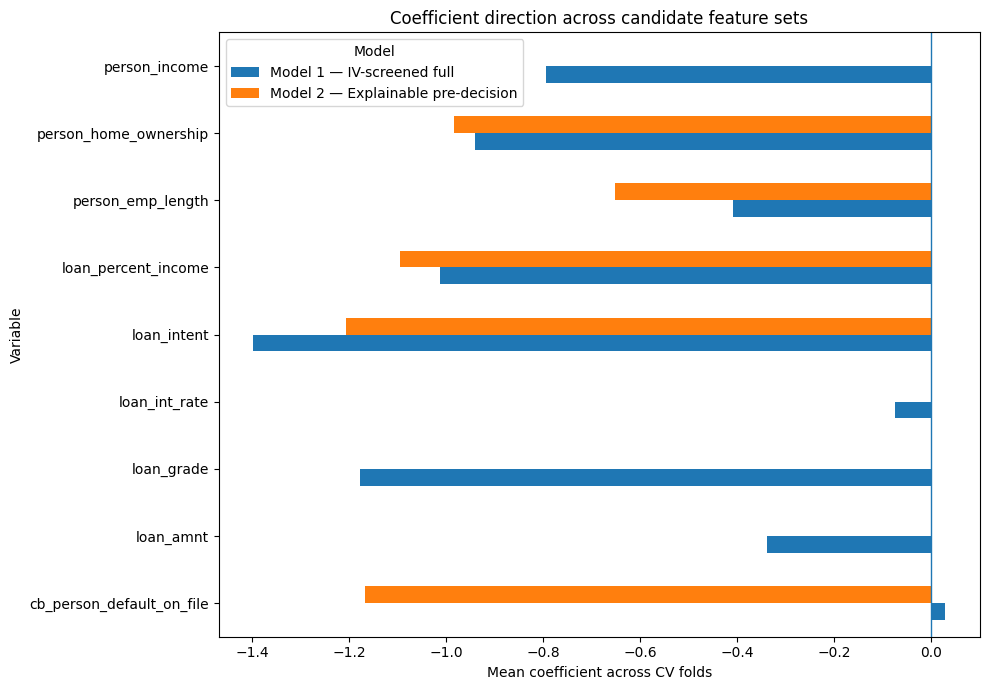

In [ ]:
coefficient_plot_data = (
    coefficient_stability[
        [
            "Model",
            "Variable",
            "Mean_coefficient"
        ]
    ]
    .copy()
)

coefficient_pivot = (
    coefficient_plot_data
    .pivot(
        index="Variable",
        columns="Model",
        values="Mean_coefficient"
    )
    .fillna(0)
)

coefficient_pivot.plot(
    kind="barh",
    figsize=(10, 7)
)

plt.axvline(
    0,
    linewidth=1
)

plt.xlabel("Mean coefficient across CV folds")
plt.ylabel("Variable")
plt.title(
    "Coefficient direction across candidate feature sets"
)

plt.tight_layout()
plt.show()

### Nhận xét

Phần lớn các hệ số có dấu âm ổn định qua toàn bộ các folds, phù hợp
với quy ước WOE được sử dụng.

Riêng `cb_person_default_on_file` có hệ số trung bình dương và rất
gần 0 trong Mô hình 1, nhưng trở thành hệ số âm mạnh trong Mô hình 2.

Sự đảo dấu này cho thấy đóng góp của biến phụ thuộc đáng kể vào việc
có mặt của `loan_grade`, `loan_int_rate` và các biến tài chính khác.
Biến này cần được rà soát bằng các mô hình trung gian trước khi diễn
giải hệ số cuối cùng.

# Kiểm tra bằng quy tắc 1-SE

Ngưỡng một sai số chuẩn được xác định bởi:

$$
AUC_{\mathrm{1SE}}
=
AUC_{\max}
-
SE(AUC_{\max}).
$$

Trong kết quả hiện tại:

$$
AUC_{\mathrm{1SE}}
=
0.87930.
$$

Mean CV AUC của Mô hình 1 là:

$$
0.88277,
$$

nên Mô hình 1 nằm trong vùng 1-SE.

Mean CV AUC của Mô hình 2 là:

$$
0.80579,
$$

thấp hơn nhiều so với ngưỡng 0.87930.

Vì vậy, Mô hình 2 không nằm trong vùng hiệu năng gần tốt nhất.

Điều này có nghĩa là Mô hình 2 không thể được chọn với lập luận:

> Mô hình ít biến hơn nhưng có hiệu năng gần tương đương Mô hình 1.

Lập luận phù hợp hơn là:

> Mô hình 2 là một cấu trúc pre-decision giải thích được, được xây dựng dưới các ràng buộc nghiệp vụ chặt hơn và phải đánh đổi một phần đáng kể khả năng phân biệt.

In [ ]:
def apply_candidate_selection_rule(
    comparison_table
):
    table = comparison_table.copy()

    best_position = (
        table["Mean CV AUC"]
        .idxmax()
    )

    best_mean_auc = float(
        table.loc[
            best_position,
            "Mean CV AUC"
        ]
    )

    best_se_auc = float(
        table.loc[
            best_position,
            "SE CV AUC"
        ]
    )

    one_se_threshold = (
        best_mean_auc
        - best_se_auc
    )

    table["Within 1-SE"] = (
        table["Mean CV AUC"]
        >= one_se_threshold
    )

    table["Business role"] = table[
        "Model"
    ].map({
        "Model 1 — IV-screened full": (
            "Benchmark / post-decision"
        ),
        "Model 2 — Explainable pre-decision": (
            "Pre-decision candidate"
        )
    })

    model_2_row = table.loc[
        table["Model"]
        == "Model 2 — Explainable pre-decision"
    ].iloc[0]

    if bool(model_2_row["Within 1-SE"]):
        recommendation = (
            "Model 2 nằm trong vùng 1-SE. "
            "Ưu tiên Model 2 cho triển khai "
            "pre-decision vì mô hình gọn, "
            "giải thích được và không dùng "
            "biến hậu quyết định."
        )
    else:
        recommendation = (
            "Model 2 nằm ngoài vùng 1-SE. "
            "Vẫn sử dụng Model 2 nếu hệ thống "
            "bắt buộc chấm điểm trước khi có "
            "grade và lãi suất, nhưng phải báo "
            "cáo rõ mức suy giảm hiệu năng. "
            "Model 1 chỉ nên được xem là "
            "benchmark hoặc mô hình post-decision."
        )

    return (
        table,
        one_se_threshold,
        recommendation
    )

In [ ]:
(
    final_candidate_comparison,
    one_se_threshold,
    recommendation
) = apply_candidate_selection_rule(
    candidate_model_comparison
)

print(
    "Ngưỡng Mean CV AUC theo quy tắc 1-SE:",
    f"{one_se_threshold:.5f}"
)

display(
    final_candidate_comparison.style.format({
        "OOF AUC": "{:.5f}",
        "OOF Gini": "{:.5f}",
        "OOF Brier": "{:.5f}",
        "Mean CV AUC": "{:.5f}",
        "SE CV AUC": "{:.5f}",
        "Calibration intercept": "{:.4f}",
        "Calibration slope": "{:.4f}",
        "Maximum VIF": "{:.4f}"
    })
)

print("\nKHUYẾN NGHỊ:")
print(recommendation)

Ngưỡng Mean CV AUC theo quy tắc 1-SE: 0.87930


,Model,Number of features,OOF AUC,OOF Gini,OOF Brier,OOF Log Loss,Mean CV AUC,SD CV AUC,SE CV AUC,Minimum fold AUC,Maximum fold AUC,Calibration intercept,Calibration slope,Maximum VIF,Any VIF > 5,Within 1-SE,Business role
0,Model 1 — IV-screened full,9,0.88269,0.76538,0.09344,0.318367,0.88277,0.010985,0.00347,0.867120,0.907023,-0.0029,0.9971,4.2209,False,True,Benchmark / post-decision
1,Model 2 — Explainable pre-decision,5,0.80575,0.61150,0.11811,0.387742,0.80579,0.010694,0.00338,0.788701,0.822636,-0.0014,0.9987,1.0580,False,False,Pre-decision candidate



KHUYẾN NGHỊ:
Model 2 nằm ngoài vùng 1-SE. Vẫn sử dụng Model 2 nếu hệ thống bắt buộc chấm điểm trước khi có grade và lãi suất, nhưng phải báo cáo rõ mức suy giảm hiệu năng. Model 1 chỉ nên được xem là benchmark hoặc mô hình post-decision.


# Xuất kết quả Feature Selection

Các kết quả được lưu gồm:

```text
iv_screening_table.csv
selection_decision_table.csv
model_1_vif.csv
model_2_vif.csv
candidate_model_cv_comparison.csv
coefficient_stability.csv
model_feature_sets.csv
model_feature_sets.json
```

Các tệp này lưu toàn bộ lý do lựa chọn biến và kết quả kiểm tra hai cấu trúc mô hình.

Chưa lưu mô hình logistic cuối cùng vì notebook hiện tại dừng ở bước feature selection và đánh giá cấu trúc ứng viên.

In [ ]:
iv_screening_table.to_csv(
    OUTPUT_DIR / "iv_screening_table.csv",
    index=False,
    encoding="utf-8-sig"
)

selection_decision_table.to_csv(
    OUTPUT_DIR / "selection_decision_table.csv",
    index=False,
    encoding="utf-8-sig"
)

model_1_vif.to_csv(
    OUTPUT_DIR / "model_1_vif.csv",
    index=False,
    encoding="utf-8-sig"
)

model_2_vif.to_csv(
    OUTPUT_DIR / "model_2_vif.csv",
    index=False,
    encoding="utf-8-sig"
)

final_candidate_comparison.to_csv(
    OUTPUT_DIR
    / "candidate_model_cv_comparison.csv",
    index=False,
    encoding="utf-8-sig"
)

coefficient_stability.to_csv(
    OUTPUT_DIR
    / "coefficient_stability.csv",
    index=False,
    encoding="utf-8-sig"
)

feature_set_summary.to_csv(
    OUTPUT_DIR
    / "model_feature_sets.csv",
    index=False,
    encoding="utf-8-sig"
)

In [ ]:
feature_selection_metadata = {
    "target": TARGET,
    "iv_threshold": IV_THRESHOLD,
    "vif_threshold": VIF_THRESHOLD,
    "low_iv_features": LOW_IV_FEATURES,
    "post_decision_features": (
        POST_DECISION_FEATURES
    ),
    "redundant_financial_group": (
        REDUNDANT_FINANCIAL_GROUP
    ),
    "redundancy_keep": REDUNDANCY_KEEP,
    "redundancy_drop": REDUNDANCY_DROP,
    "model_feature_sets": (
        model_feature_sets
    ),
    "one_se_threshold": float(
        one_se_threshold
    ),
    "recommendation": recommendation,
    "test_usage": (
        "Tập test chưa được sử dụng trong "
        "feature selection."
    )
}

with open(
    OUTPUT_DIR / "model_feature_sets.json",
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        feature_selection_metadata,
        file,
        ensure_ascii=False,
        indent=4
    )

print("Đã lưu kết quả tại:")
print(OUTPUT_DIR)

Đã lưu kết quả tại:
/content/drive/MyDrive/AIO 2026/Conquer/Data/train_test_feature_selection/explainable_feature_selection


# Kết luận Feature Selection

Feature selection được thực hiện theo hướng rule-based và giải thích
được, gồm ba bước:

$$
\text{IV screening}
\rightarrow
\text{prediction-timestamp review}
\rightarrow
\text{redundancy reduction}.
$$

Hai biến `person_age` và `cb_person_cred_hist_length` bị loại vì có
IV thấp hơn 0.02.

Mô hình 1 giữ chín biến vượt IV screening và đóng vai trò benchmark.
Mô hình này đạt OOF AUC khoảng 0.883 và OOF Gini khoảng 0.765. Không
biến nào có VIF vượt 5, nhưng `loan_grade` và `loan_int_rate` có VIF
cao nhất và chứa thông tin tương đối chồng lặp.

Mô hình 2 loại `loan_grade` và `loan_int_rate` để bảo đảm tính hợp lệ
tại prediction timestamp. Mô hình cũng chỉ giữ
`loan_percent_income` trong nhóm gồm `loan_percent_income`,
`loan_amnt` và `person_income`.

Sau khi giảm xuống năm biến, maximum VIF giảm từ khoảng 4.22 xuống
1.06. Tuy nhiên, OOF AUC giảm từ khoảng 0.883 xuống 0.806 và OOF
Gini giảm từ khoảng 0.765 xuống 0.612. Mô hình 2 nằm ngoài vùng 1-SE,
cho thấy mức suy giảm khả năng phân biệt là đáng kể.

Vì vậy:

- Mô hình 1 được giữ làm benchmark hoặc cấu trúc post-decision.
- Mô hình 2 là cấu trúc pre-decision giải thích được, nhưng không có
  hiệu năng gần tương đương Mô hình 1.
- Sự lựa chọn giữa hai cấu trúc phụ thuộc trước hết vào prediction
  timestamp, không chỉ vào AUC hoặc Gini.
- Cần bổ sung một cấu trúc trung gian chỉ loại `loan_grade` và
  `loan_int_rate` để tách riêng chi phí của ràng buộc pre-decision
  khỏi chi phí của việc loại `person_income` và `loan_amnt`. (optional)
- `cb_person_default_on_file` cần được rà soát thêm do hệ số đảo dấu
  giữa hai cấu trúc.

Tập test vẫn được giữ nguyên và chưa được sử dụng trong feature
selection.

# Preparation for Model Development

Feature Selection dừng tại việc xác định và đánh giá các tập biến ứng viên.  
Để bảo đảm notebook xây dựng mô hình có thể chạy độc lập, các tệp cần thiết được lưu ra ngoài:

```text
train_woe_dataset.csv
test_woe_dataset.csv
train_bin_dataset.csv
test_bin_dataset.csv
binning_models.joblib
cleaned_binning_tables.joblib
model_feature_sets.json
feature_selection_manifest.json
```


In [ ]:
# ============================================================
# XUẤT ARTIFACT CHO NOTEBOOK MODEL DEVELOPMENT
# ============================================================

# Tạo lại các tập biến một cách tường minh để notebook có thể
# chạy lại từ đầu mà không phụ thuộc vào biến còn sót trong RAM.
MODEL_INTERMEDIATE_FEATURES = [
    feature
    for feature in MODEL_1_FEATURES
    if feature not in POST_DECISION_FEATURES
]

model_feature_sets = {
    "model_1_iv_screened_full": MODEL_1_FEATURES,
    "model_intermediate_predecision_full_financial": (
        MODEL_INTERMEDIATE_FEATURES
    ),
    "model_2_explainable_predecision": MODEL_2_FEATURES
}

feature_set_summary = pd.DataFrame([
    {
        "Model key": model_key,
        "Number of features": len(features),
        "Features": " | ".join(features)
    }
    for model_key, features in model_feature_sets.items()
])

display(feature_set_summary)

# Lưu dữ liệu WOE và bin assignment với original_index để có thể
# đối chiếu lại với dữ liệu gốc.
train_woe_dataset.to_csv(
    OUTPUT_DIR / "train_woe_dataset.csv",
    index=True,
    index_label="original_index",
    encoding="utf-8-sig"
)

test_woe_dataset.to_csv(
    OUTPUT_DIR / "test_woe_dataset.csv",
    index=True,
    index_label="original_index",
    encoding="utf-8-sig"
)

train_bin_dataset.to_csv(
    OUTPUT_DIR / "train_bin_dataset.csv",
    index=True,
    index_label="original_index",
    encoding="utf-8-sig"
)

test_bin_dataset.to_csv(
    OUTPUT_DIR / "test_bin_dataset.csv",
    index=True,
    index_label="original_index",
    encoding="utf-8-sig"
)

# Lưu các object binning đã fit trên train.
joblib.dump(
    binning_models,
    OUTPUT_DIR / "binning_models.joblib"
)

joblib.dump(
    cleaned_binning_tables,
    OUTPUT_DIR / "cleaned_binning_tables.joblib"
)

# Full tables giữ cả Missing/Special bins để tạo scorecard đầy đủ.
joblib.dump(
    binning_tables,
    OUTPUT_DIR / "binning_tables.joblib"
)

# Ghi lại metadata và tập biến một cách tái lập.
feature_selection_metadata = {
    "target": TARGET,
    "iv_threshold": IV_THRESHOLD,
    "vif_threshold": VIF_THRESHOLD,
    "random_state": RANDOM_STATE,
    "n_splits": N_SPLITS,
    "low_iv_features": LOW_IV_FEATURES,
    "post_decision_features": POST_DECISION_FEATURES,
    "redundant_financial_group": REDUNDANT_FINANCIAL_GROUP,
    "redundancy_keep": REDUNDANCY_KEEP,
    "redundancy_drop": REDUNDANCY_DROP,
    "model_feature_sets": model_feature_sets,
    "one_se_threshold": float(one_se_threshold),
    "recommendation": recommendation,
    "test_usage": (
        "Tập test chưa được dùng để điều chỉnh feature selection."
    )
}

with open(
    OUTPUT_DIR / "model_feature_sets.json",
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        feature_selection_metadata,
        file,
        ensure_ascii=False,
        indent=4
    )

artifact_manifest = {
    "artifact_directory": str(OUTPUT_DIR),
    "required_by_model_notebook": [
        "train_woe_dataset.csv",
        "test_woe_dataset.csv",
        "train_bin_dataset.csv",
        "test_bin_dataset.csv",
        "cleaned_binning_tables.joblib",
        "binning_tables.joblib",
        "model_feature_sets.json"
    ],
    "optional_artifacts": [
        "binning_models.joblib",
        "iv_screening_table.csv",
        "selection_decision_table.csv",
        "candidate_model_cv_comparison.csv",
        "coefficient_stability.csv"
    ]
}

with open(
    OUTPUT_DIR / "feature_selection_manifest.json",
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        artifact_manifest,
        file,
        ensure_ascii=False,
        indent=4
    )

print("Đã xuất artifact cho Model Development tại:")
print(OUTPUT_DIR)

,Model key,Number of features,Features
0,model_1_iv_screened_full,9,person_income | person_home_ownership | person...
1,model_intermediate_predecision_full_financial,7,person_income | person_home_ownership | person...
2,model_2_explainable_predecision,5,person_home_ownership | person_emp_length | lo...


Đã xuất artifact cho Model Development tại:
/content/drive/MyDrive/AIO 2026/Conquer/Data/train_test_feature_selection/explainable_feature_selection
